# Dataset Visualization

Visual inspection of the spike-encoded datasets used by the SNN framework:
1. MNIST after Difference-of-Gaussians (DoG) filtering
2. CIFAR-10 after whitening kernel preprocessing (Falez 2020)

In [1]:
import os
os.chdir("..")

import matplotlib.pyplot as plt
import torch
import torchvision

from spiking.preprocessing import (
    apply_difference_of_gaussians_filter,
    apply_latency_encoding,
    discretize_times,
)
from applications.datasets import MnistDataset

## 1. MNIST after Difference-of-Gaussians

In [2]:
mnist = MnistDataset("data", "test")
print(f"MNIST test: {len(mnist)} images")
print(f"  inputs shape: {mnist.inputs.shape}")
print(f"  all_times shape: {mnist.all_times.shape}")

MNIST test: 10000 images
  inputs shape: torch.Size([10000, 28, 28])
  all_times shape: torch.Size([10000, 2, 28, 28])


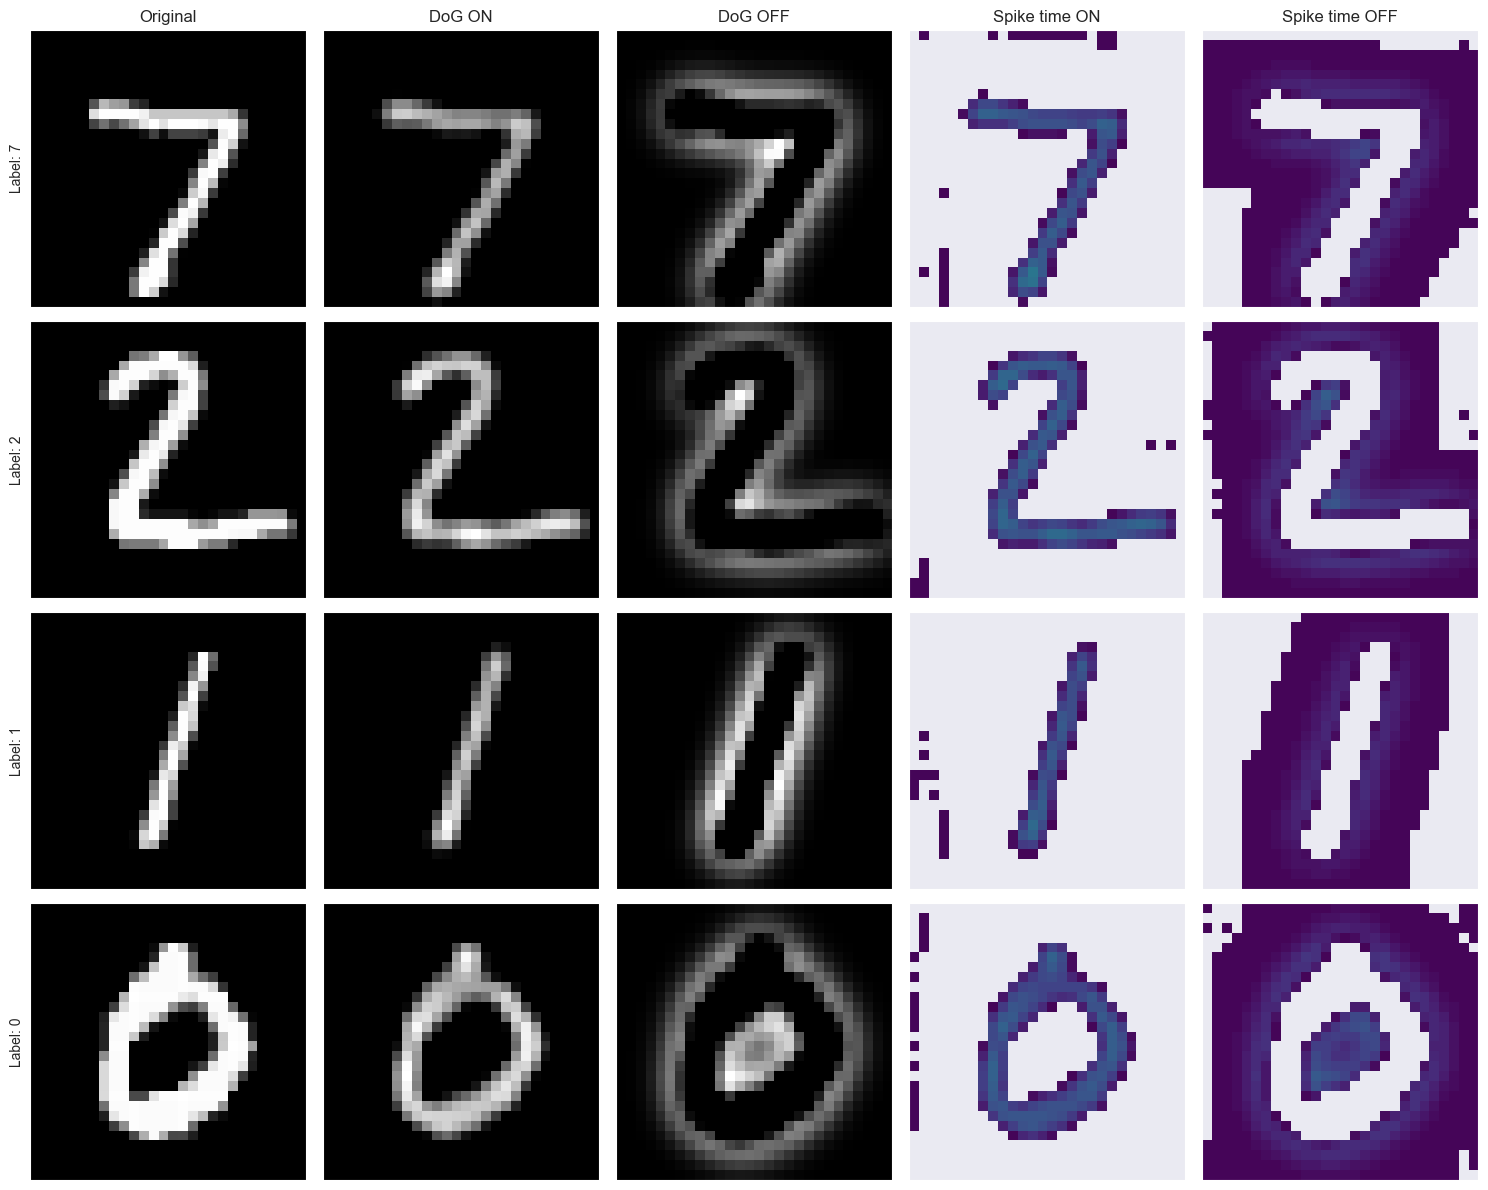

In [3]:
N_SAMPLES = 4

fig, axes = plt.subplots(N_SAMPLES, 5, figsize=(15, 3 * N_SAMPLES))
col_titles = ["Original", "DoG ON", "DoG OFF", "Spike time ON", "Spike time OFF"]

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title)

for row in range(N_SAMPLES):
    img = mnist.inputs[row]
    dog = apply_difference_of_gaussians_filter(img)
    times = mnist.all_times[row]
    label = mnist.outputs[row].item()

    # Replace inf with NaN for display (shows as white)
    times_display = times.clone()
    times_display[~torch.isfinite(times_display)] = float("nan")

    axes[row, 0].imshow(img, cmap="gray")
    axes[row, 0].set_ylabel(f"Label: {label}")
    axes[row, 1].imshow(dog[0], cmap="gray")
    axes[row, 2].imshow(dog[1], cmap="gray")
    axes[row, 3].imshow(times_display[0], cmap="viridis_r", vmin=0, vmax=1)
    axes[row, 4].imshow(times_display[1], cmap="viridis_r", vmin=0, vmax=1)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

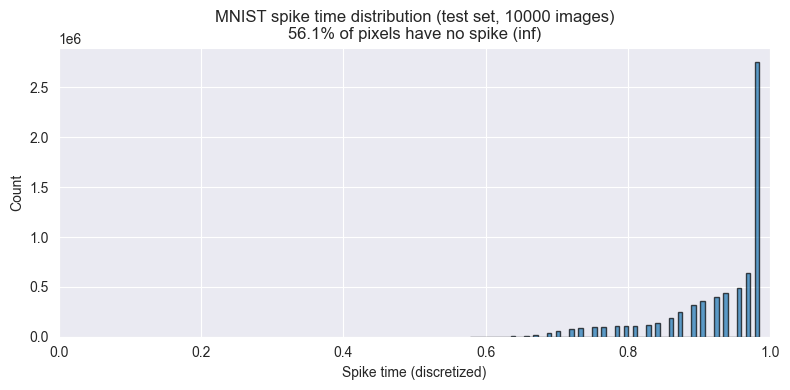

In [4]:
all_times_flat = mnist.all_times.ravel()
finite_times = all_times_flat[torch.isfinite(all_times_flat)]
inf_fraction = 1.0 - len(finite_times) / len(all_times_flat)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(finite_times.numpy(), bins=64, edgecolor="black", alpha=0.7)
ax.set_xlabel("Spike time (discretized)")
ax.set_ylabel("Count")
ax.set_title(
    f"MNIST spike time distribution (test set, {len(mnist)} images)\n"
    f"{inf_fraction:.1%} of pixels have no spike (inf)"
)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

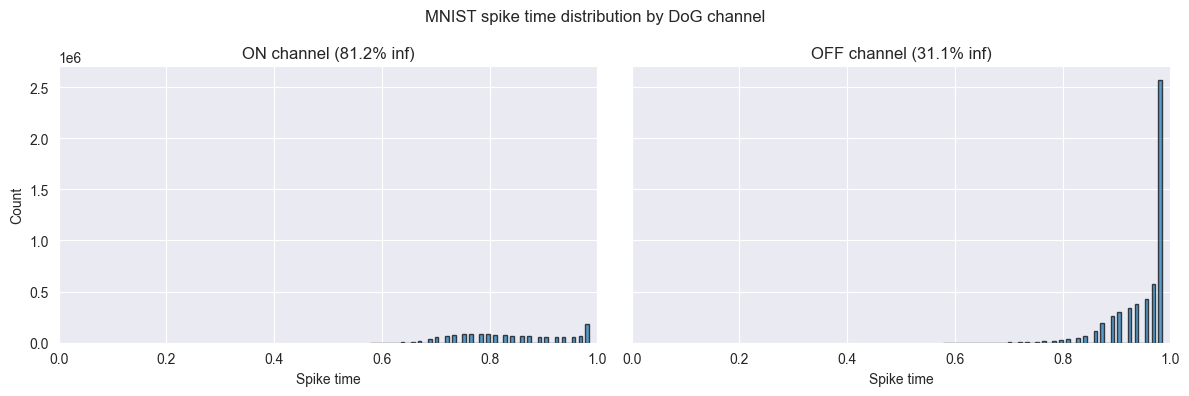

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
channel_names = ["ON", "OFF"]

for ch, (ax, name) in enumerate(zip(axes, channel_names)):
    ch_times = mnist.all_times[:, ch].ravel()
    finite = ch_times[torch.isfinite(ch_times)]
    inf_frac = 1.0 - len(finite) / len(ch_times)
    ax.hist(finite.numpy(), bins=64, edgecolor="black", alpha=0.7)
    ax.set_title(f"{name} channel ({inf_frac:.1%} inf)")
    ax.set_xlabel("Spike time")
    ax.set_xlim(0, 1)

axes[0].set_ylabel("Count")
fig.suptitle("MNIST spike time distribution by DoG channel")
plt.tight_layout()
plt.show()

## 2. CIFAR-10 after Whitening Kernels

In [6]:
# Load raw CIFAR-10 for display alongside whitened versions
cifar_raw = torchvision.datasets.CIFAR10("data", train=False, download=True)
raw_images = torch.from_numpy(cifar_raw.data).float() / 255.0  # (N, 32, 32, 3)

# Load pre-processed whitened+encoded images
PROCESSED_DIR = "data/processed-cifar10"
test_data = torch.load(f"{PROCESSED_DIR}/test.pt", weights_only=True)
test_times = test_data["images"]   # (N, 6, 32, 32)
test_labels = test_data["labels"]  # (N,)

print(f"CIFAR-10 test: {len(test_labels)} images")
print(f"  test_times shape: {test_times.shape}")

Files already downloaded and verified
CIFAR-10 test: 10000 images
  test_times shape: torch.Size([10000, 6, 32, 32])


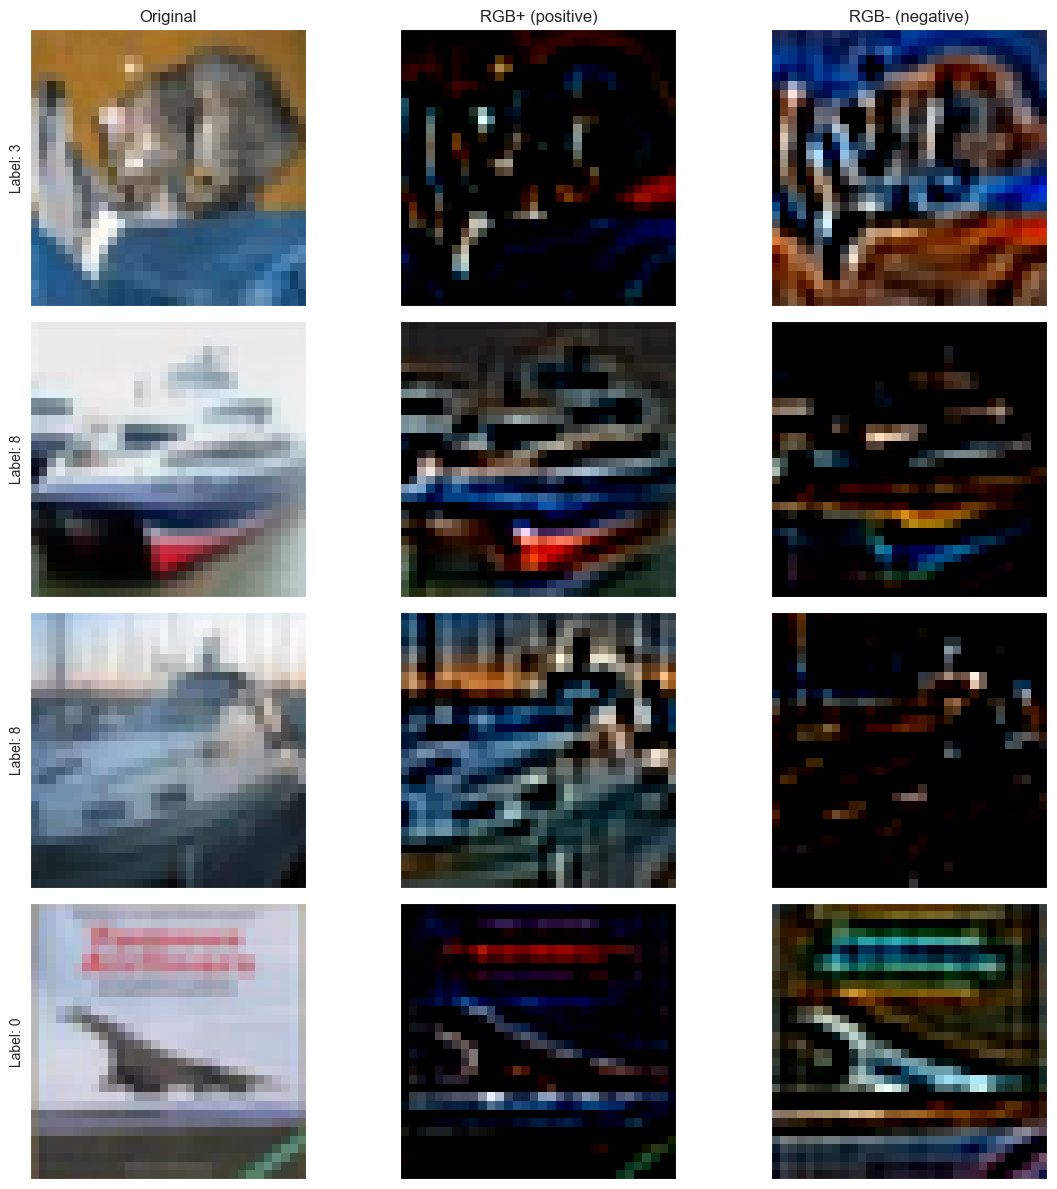

In [7]:
N_SAMPLES = 4

fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(12, 3 * N_SAMPLES))
col_titles = ["Original", "RGB+ (positive)", "RGB- (negative)"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title)

# Interleaved channels: [R+, R-, G+, G-, B+, B-]
POS_CHANNELS = [0, 2, 4]  # R+, G+, B+
NEG_CHANNELS = [1, 3, 5]  # R-, G-, B-

for row in range(N_SAMPLES):
    times = test_times[row]  # (6, 32, 32)
    label = test_labels[row].item()

    axes[row, 0].imshow(raw_images[row])
    axes[row, 0].set_ylabel(f"Label: {label}")

    for col, channels in enumerate([POS_CHANNELS, NEG_CHANNELS], start=1):
        # spike time → intensity: 1 - t (early spike = bright), inf → 0 (black)
        rgb = torch.zeros(32, 32, 3)
        for i, ch in enumerate(channels):
            t = times[ch].clone()
            t[~torch.isfinite(t)] = 1.0  # inf → intensity 0
            rgb[:, :, i] = torch.clamp(1.0 - t, 0.0, 1.0)
        axes[row, col].imshow(rgb.numpy())

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

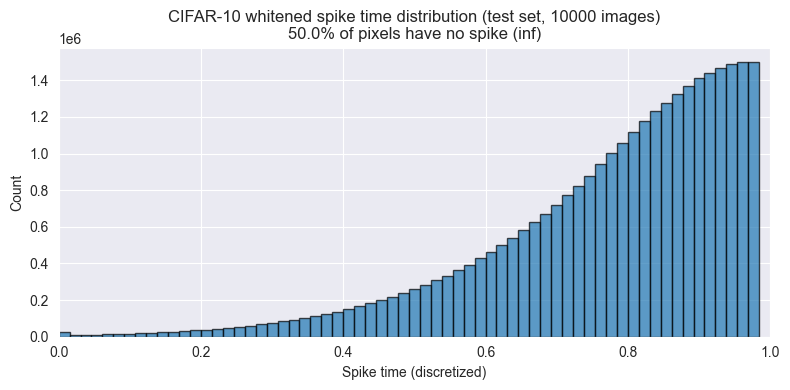

In [8]:
all_times_flat = test_times.ravel()
finite_times = all_times_flat[torch.isfinite(all_times_flat)]
inf_fraction = 1.0 - len(finite_times) / len(all_times_flat)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(finite_times.numpy(), bins=64, edgecolor="black", alpha=0.7)
ax.set_xlabel("Spike time (discretized)")
ax.set_ylabel("Count")
ax.set_title(
    f"CIFAR-10 whitened spike time distribution (test set, {len(test_labels)} images)\n"
    f"{inf_fraction:.1%} of pixels have no spike (inf)"
)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

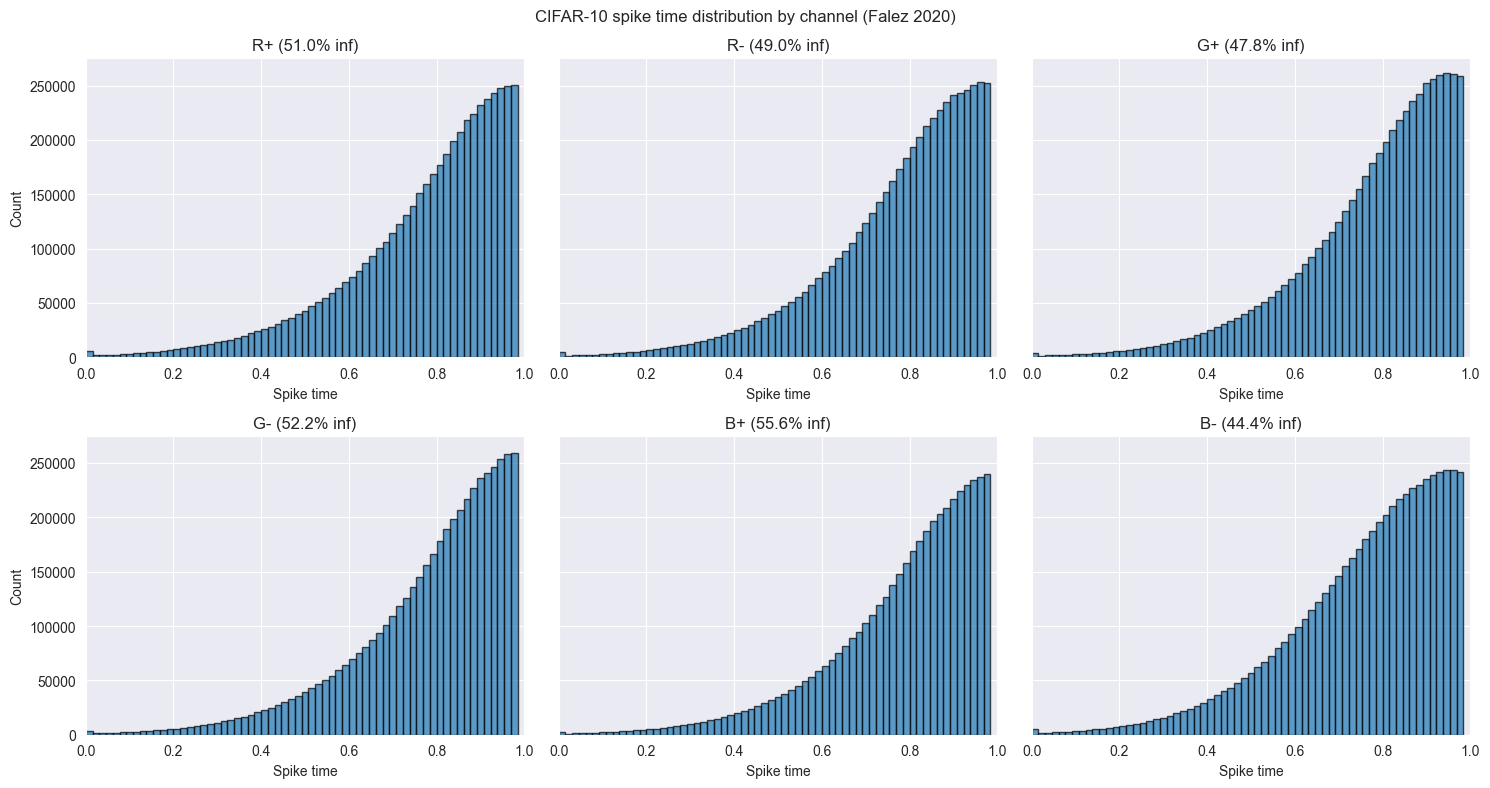

In [9]:
CHANNEL_NAMES = ["R+", "R-", "G+", "G-", "B+", "B-"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

for ch, (ax, name) in enumerate(zip(axes.ravel(), CHANNEL_NAMES)):
    ch_times = test_times[:, ch].ravel()
    finite = ch_times[torch.isfinite(ch_times)]
    inf_frac = 1.0 - len(finite) / len(ch_times)
    ax.hist(finite.numpy(), bins=64, edgecolor="black", alpha=0.7)
    ax.set_title(f"{name} ({inf_frac:.1%} inf)")
    ax.set_xlabel("Spike time")
    ax.set_xlim(0, 1)

axes[0, 0].set_ylabel("Count")
axes[1, 0].set_ylabel("Count")
fig.suptitle("CIFAR-10 spike time distribution by channel (Falez 2020)")
plt.tight_layout()
plt.show()

## Observations

**MNIST DoG**:

**CIFAR-10 whitening**: